<a href="https://colab.research.google.com/github/kshri77/Automated-Notice-Generation/blob/main/MINIPROJECT_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cell 2: All Imports
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, f1_score, precision_score,
                             recall_score, roc_auc_score, roc_curve)
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

print("TensorFlow version:", tf.__version__)
print("All imports successful.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TensorFlow version: 2.19.0
All imports successful.


In [ ]:
# Cell 3: Data Loading (Optimized for Balanced Research)
import pandas as pd
import glob

folder_path = '/content/drive/MyDrive/MP-4-Dataset/'

# 1. Load the Balanced IoT Telemetry File (Physical Branch)
# Using the "Train_Test" version ensures we have attack samples!
iot_file = folder_path + "Train_Test_IoT_Motion_Light.csv"
df_tel = pd.read_csv(iot_file, low_memory=False)

print(f"--- IoT Physical Data ---")
print(f"File: {iot_file.split('/')[-1]}")
print(f"Shape: {df_tel.shape}")
# Verify attacks exist
if 'label' in df_tel.columns:
    print(f"Attack counts:\n{df_tel['label'].value_counts()}")

# 2. Load the Balanced Network Dataset (Cyber Branch)
# This file is designed for training and includes diverse attack types
net_file = folder_path + "train_test_network.csv"
df_net = pd.read_csv(net_file, low_memory=False)

print(f"\n--- Network Cyber Data ---")
print(f"File: {net_file.split('/')[-1]}")
print(f"Shape: {df_net.shape}")
# Verify attacks exist
if 'label' in df_net.columns:
    print(f"Attack counts:\n{df_net['label'].value_counts()}")

# Final Check
print("\nLoading Complete. Please proceed to Preprocessing (Cell 5).")


--- IoT Physical Data ---
File: Train_Test_IoT_Motion_Light.csv
Shape: (39488, 6)
Attack counts:
label
1    24488
0    15000
Name: count, dtype: int64

--- Network Cyber Data ---
File: train_test_network.csv
Shape: (211043, 44)
Attack counts:
label
1    161043
0     50000
Name: count, dtype: int64

Loading Complete. Please proceed to Preprocessing (Cell 5).


In [ ]:
# Cell 4: Preprocessing — Network Data (Cyber Branch)

df_cyber = df_net.copy()

# ── Step 1: Drop duplicates & fully-null rows ──────────────────────────────
df_cyber.drop_duplicates(inplace=True)
df_cyber.dropna(how='all', inplace=True)
print("After dedup/dropna:", df_cyber.shape)

# ── Step 2: Identify label column ─────────────────────────────────────────
# TON_IoT network files typically have 'label' or 'type' column
label_col_net = None
for candidate in ['label', 'Label', 'type', 'Type', 'attack_type', 'attack']:
    if candidate in df_cyber.columns:
        label_col_net = candidate
        break

if label_col_net is None:
    raise ValueError("No label column found in network data. Columns: " + str(df_cyber.columns.tolist()))
print(f"Network label column: '{label_col_net}'")
print("Class distribution:\n", df_cyber[label_col_net].value_counts())

# ── Step 3: Binary label (0=normal, 1=attack) ─────────────────────────────
df_cyber['binary_label'] = df_cyber[label_col_net].apply(
    lambda x: 0 if str(x).strip().lower() in ['normal', '0', 'benign'] else 1
)
print("\nBinary label distribution:\n", df_cyber['binary_label'].value_counts())

# ── Step 4: Drop non-feature columns ──────────────────────────────────────
drop_cols_net = [label_col_net, 'binary_label']
# Drop IP/timestamp columns if present
for col in ['src_ip', 'dst_ip', 'ts', 'timestamp', 'Timestamp', 'saddr', 'daddr', 'soui', 'doui']:
    if col in df_cyber.columns:
        drop_cols_net.append(col)

X_cyber_raw = df_cyber.drop(columns=drop_cols_net, errors='ignore')
y_cyber = df_cyber['binary_label'].values

# ── Step 5: Label Encoding for categorical columns ────────────────────────
le = LabelEncoder()
for col in X_cyber_raw.select_dtypes(include=['object', 'category']).columns:
    X_cyber_raw[col] = le.fit_transform(X_cyber_raw[col].astype(str))

# ── Step 6: Fill remaining NaNs with median ───────────────────────────────
X_cyber_raw.fillna(X_cyber_raw.median(numeric_only=True), inplace=True)

# ── Step 7: Noise Removal — clip extreme outliers (IQR method) ────────────
Q1 = X_cyber_raw.quantile(0.01)
Q3 = X_cyber_raw.quantile(0.99)
X_cyber_raw = X_cyber_raw.clip(lower=Q1, upper=Q3, axis=1)

# ── Step 8: Feature Scaling (StandardScaler) ──────────────────────────────
scaler_cyber = StandardScaler()
X_cyber_scaled = scaler_cyber.fit_transform(X_cyber_raw)

print(f"\nFinal Cyber Feature Matrix: {X_cyber_scaled.shape}")
print(f"Label vector: {y_cyber.shape}, Attacks: {y_cyber.sum()}, Normal: {(y_cyber==0).sum()}")

After dedup/dropna: (190474, 44)
Network label column: 'label'
Class distribution:
 label
1    148434
0     42040
Name: count, dtype: int64

Binary label distribution:
 binary_label
1    148434
0     42040
Name: count, dtype: int64

Final Cyber Feature Matrix: (190474, 41)
Label vector: (190474,), Attacks: 148434, Normal: 42040


In [ ]:
# Cell 5: Preprocessing — IoT Telemetry (Physical Branch)

df_phys = df_tel.copy()

# ── Step 1: Clean ──────────────────────────────────────────────────────────
df_phys.drop_duplicates(inplace=True)
df_phys.dropna(how='all', inplace=True)
print("After dedup/dropna:", df_phys.shape)
print("IoT Columns:", df_phys.columns.tolist())

# ── Step 2: Identify label column ─────────────────────────────────────────
label_col_iot = None
for candidate in ['label', 'Label', 'type', 'Type', 'attack_type']:
    if candidate in df_phys.columns:
        label_col_iot = candidate
        break

if label_col_iot is None:
    raise ValueError("No label column found in IoT data. Columns: " + str(df_phys.columns.tolist()))
print(f"IoT label column: '{label_col_iot}'")
print("Class distribution:\n", df_phys[label_col_iot].value_counts())

# ── Step 3: Binary label ──────────────────────────────────────────────────
df_phys['binary_label'] = df_phys[label_col_iot].apply(
    lambda x: 0 if str(x).strip().lower() in ['normal', '0', 'benign'] else 1
)
print("\nBinary label distribution:\n", df_phys['binary_label'].value_counts())

# ── Step 4: Drop non-feature columns ──────────────────────────────────────
drop_cols_iot = [label_col_iot, 'binary_label']
for col in ['ts', 'timestamp', 'Timestamp', 'device', 'Device']:
    if col in df_phys.columns:
        drop_cols_iot.append(col)

X_phys_raw = df_phys.drop(columns=drop_cols_iot, errors='ignore')
y_phys = df_phys['binary_label'].values

# ── Step 5: Label Encoding for categorical columns ────────────────────────
le2 = LabelEncoder()
for col in X_phys_raw.select_dtypes(include=['object', 'category']).columns:
    X_phys_raw[col] = le2.fit_transform(X_phys_raw[col].astype(str))

# ── Step 6: Fill NaNs ─────────────────────────────────────────────────────
X_phys_raw.fillna(X_phys_raw.median(numeric_only=True), inplace=True)

# ── Step 7: Noise Removal ─────────────────────────────────────────────────
Q1p = X_phys_raw.quantile(0.01)
Q3p = X_phys_raw.quantile(0.99)
X_phys_raw = X_phys_raw.clip(lower=Q1p, upper=Q3p, axis=1)

# ── Step 8: Feature Scaling ───────────────────────────────────────────────
scaler_phys = MinMaxScaler()
X_phys_scaled = scaler_phys.fit_transform(X_phys_raw)

print(f"\nFinal IoT Feature Matrix: {X_phys_scaled.shape}")
print(f"Label vector: {y_phys.shape}, Attacks: {y_phys.sum()}, Normal: {(y_phys==0).sum()}")

After dedup/dropna: (25830, 6)
IoT Columns: ['date', 'time', 'motion_status', 'light_status', 'label', 'type']
IoT label column: 'label'
Class distribution:
 label
1    22381
0     3449
Name: count, dtype: int64

Binary label distribution:
 binary_label
1    22381
0     3449
Name: count, dtype: int64

Final IoT Feature Matrix: (25830, 5)
Label vector: (25830,), Attacks: 22381, Normal: 3449


In [ ]:
# Cell 5: Preprocessing — IoT Telemetry (Physical Branch)

import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

df_phys = df_tel.copy()

# ── Step 1: Clean ──────────────────────────────────────────────────────────
df_phys.drop_duplicates(inplace=True)
df_phys.dropna(how='all', inplace=True)
print(f"After dedup/dropna: {df_phys.shape}")

# ── Step 2: Identify label column ─────────────────────────────────────────
label_col_iot = None
# Added 'label' and 'Label' to priority list as they are common in ToN_IoT
for candidate in ['label', 'Label', 'type', 'Type', 'attack_type']:
    if candidate in df_phys.columns:
        label_col_iot = candidate
        break

if label_col_iot is None:
    raise ValueError("No label column found. Columns: " + str(df_phys.columns.tolist()))

print(f"IoT label column identified: '{label_col_iot}'")
print("Original Class distribution:\n", df_phys[label_col_iot].value_counts())

# ── Step 3: Improved Binary Labeling ──────────────────────────────────────
# This version ensures that if the column is already 0/1 (numeric), it stays that way.
# If it's text (like 'backdoor', 'ddos'), it becomes 1.
def convert_to_binary(x):
    val = str(x).strip().lower()
    if val in ['normal', '0', '0.0', 'benign', 'n']:
        return 0
    return 1

df_phys['binary_label'] = df_phys[label_col_iot].apply(convert_to_binary)
print("\nNew Binary label distribution:\n", df_phys['binary_label'].value_counts())

# ── Step 4: Drop non-feature columns ──────────────────────────────────────
# We drop the original label and our new binary label, plus metadata
drop_cols_iot = [label_col_iot, 'binary_label']
metadata_cols = ['ts', 'timestamp', 'Timestamp', 'device', 'Device', 'date', 'time']
for col in metadata_cols:
    if col in df_phys.columns:
        drop_cols_iot.append(col)

X_phys_raw = df_phys.drop(columns=drop_cols_iot, errors='ignore')
y_phys = df_phys['binary_label'].values

# ── Step 5: Label Encoding for categorical columns ────────────────────────
le2 = LabelEncoder()
categorical_cols = X_phys_raw.select_dtypes(include=['object', 'category']).columns
for col in categorical_cols:
    X_phys_raw[col] = le2.fit_transform(X_phys_raw[col].astype(str))

# ── Step 6: Handle Missing Values ─────────────────────────────────────────
if X_phys_raw.isnull().values.any():
    X_phys_raw.fillna(X_phys_raw.median(numeric_only=True), inplace=True)
    # Final fallback for columns with NO numeric data
    X_phys_raw.fillna(0, inplace=True)

# ── Step 7: Noise Removal (Outlier Clipping) ──────────────────────────────
Q1p = X_phys_raw.quantile(0.01)
Q3p = X_phys_raw.quantile(0.99)
X_phys_raw = X_phys_raw.clip(lower=Q1p, upper=Q3p, axis=1)

# ── Step 8: Feature Scaling ───────────────────────────────────────────────
scaler_phys = MinMaxScaler()
X_phys_scaled = scaler_phys.fit_transform(X_phys_raw)

print(f"\nFinal IoT Feature Matrix shape: {X_phys_scaled.shape}")
print(f"Total Samples: {len(y_phys)}")
print(f"Attack Samples (1): {y_phys.sum()}")
print(f"Normal Samples (0): {(y_phys==0).sum()}")

# ── CRITICAL CHECK FOR ISOLATION FOREST ───────────────────────────────────
if y_phys.sum() == 0:
    print("\n[WARNING] Still 0 attacks found. Isolation Forest will need 'contamination=auto'.")
    print("Please check if your CSV file (df_tel) actually contains attack data.")


After dedup/dropna: (25830, 6)
IoT label column identified: 'label'
Original Class distribution:
 label
1    22381
0     3449
Name: count, dtype: int64

New Binary label distribution:
 binary_label
1    22381
0     3449
Name: count, dtype: int64

Final IoT Feature Matrix shape: (25830, 3)
Total Samples: 25830
Attack Samples (1): 22381
Normal Samples (0): 3449


In [ ]:
# Cell 6: Train/Test Split + SMOTE for class imbalance
from sklearn.model_selection import train_test_split
# ── Cyber (Network) Split ─────────────────────────────────────────────────
X_c_train, X_c_test, y_c_train, y_c_test = train_test_split(
    X_cyber_scaled, y_cyber, test_size=0.2, random_state=42, stratify=y_cyber
)

# SMOTE on training set only
sm = SMOTE(random_state=42)
X_c_train_sm, y_c_train_sm = sm.fit_resample(X_c_train, y_c_train)
print(f"Cyber Train (after SMOTE): {X_c_train_sm.shape}, Labels: {np.bincount(y_c_train_sm)}")
print(f"Cyber Test: {X_c_test.shape}")

# ── IoT (Physical) Split ──────────────────────────────────────────────────
X_p_train, X_p_test, y_p_train, y_p_test = train_test_split(
    X_phys_scaled, y_phys, test_size=0.2, random_state=42, stratify=y_phys
)
print(f"\nIoT Train: {X_p_train.shape}, Test: {X_p_test.shape}")

Cyber Train (after SMOTE): (237494, 41), Labels: [118747 118747]
Cyber Test: (38095, 41)

IoT Train: (20664, 3), Test: (5166, 3)


In [ ]:
# Cell 7: LSTM Model — Cyber Detection Branch
# Reshape for LSTM: (samples, timesteps=1, features)

TIMESTEPS = 1

X_c_train_lstm = X_c_train_sm.reshape(X_c_train_sm.shape[0], TIMESTEPS, X_c_train_sm.shape[1])
X_c_test_lstm  = X_c_test.reshape(X_c_test.shape[0],  TIMESTEPS, X_c_test.shape[1])

n_features = X_c_train_sm.shape[1]

# ── Build LSTM ────────────────────────────────────────────────────────────
def build_lstm(n_features, timesteps=1):
    inp = Input(shape=(timesteps, n_features))
    x = LSTM(128, return_sequences=True)(inp)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = LSTM(64, return_sequences=False)(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = Dense(32, activation='relu')(x)
    x = Dropout(0.2)(x)
    out = Dense(1, activation='sigmoid')(x)         # binary output
    model = Model(inputs=inp, outputs=out)
    return model

lstm_model = build_lstm(n_features, TIMESTEPS)
lstm_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
lstm_model.summary()

# ── Callbacks ─────────────────────────────────────────────────────────────
callbacks_lstm = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint('/content/best_lstm.keras', save_best_only=True, monitor='val_accuracy', verbose=0)
]

# ── Train ──────────────────────────────────────────────────────────────────
# 40 epochs: empirically improves over base-paper's typical 20-30
# EarlyStopping prevents overfitting; val_accuracy converges ~35-40 epochs on TON_IoT
EPOCHS_LSTM = 40
BATCH_SIZE  = 512   # large batch -> faster on Colab GPU

history_lstm = lstm_model.fit(
    X_c_train_lstm, y_c_train_sm,
    epochs=EPOCHS_LSTM,
    batch_size=BATCH_SIZE,
    validation_split=0.15,
    callbacks=callbacks_lstm,
    verbose=1
)
print("\nLSTM Training complete.")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1, 41)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 1, 128)         │        87,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 139,329 (544.25 KB)

 Trainable params: 138,945 (542.75 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/40
395/395 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.9818 - loss: 0.0558 - val_accuracy: 0.9992 - val_loss: 0.0133 - learning_rate: 0.0010
Epoch 2/40
395/395 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9985 - loss: 0.0052 - val_accuracy: 0.9997 - val_loss: 9.1378e-04 - learning_rate: 0.0010
Epoch 3/40
395/395 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9995 - loss: 0.0018 - val_accuracy: 1.0000 - val_loss: 7.2843e-05 - learning_rate: 0.0010
Epoch 4/40
395/395 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9995 - loss: 0.0019 - val_accuracy: 1.0000 - val_loss: 6.2332e-05 - learning_rate: 0.0010
Epoch 5/40
395/395 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9998 - loss: 6.6016e-04 - val_accuracy: 1.0000 - val_loss: 1.0769e-05 - learning_rate: 0.0010
Epoch 6/40
394/395 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9998 - loss: 7.4525e-04
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
395/395 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - ac

In [ ]:
print(f"Total samples in y_p_train: {len(y_p_train)}")
print(f"Attack samples in y_p_train: {y_p_train.sum()}")


Total samples in y_p_train: 20664
Attack samples in y_p_train: 17905


In [ ]:
-# Cell 8: Isolation Forest — Physical Detection Branch

from sklearn.ensemble import IsolationForest
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# 1. Calculate attack fraction
attack_count = int(y_p_train.sum())
total_count = len(y_p_train)
attack_frac = float(attack_count) / total_count
print(f"IoT train attack fraction: {attack_frac:.4f}")

# 2. FIX: Constrain contamination to valid range (0.0, 0.5]
# If the dataset is mostly attacks, we use a standard outlier
# threshold (0.1) to find the most extreme deviations.
if attack_frac > 0.5:
    contamination_val = 0.1
    print(f"Attack fraction too high for IF logic (>0.5). Capping contamination at: {contamination_val}")
elif attack_frac > 0:
    contamination_val = attack_frac
    print(f"Using calculated contamination: {contamination_val:.4f}")
else:
    contamination_val = 'auto'
    print("No attacks found in training set. Using contamination: 'auto'")

# 3. Initialize and Train
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=contamination_val,
    random_state=42,
    n_jobs=-1
)

# Train ONLY on training data (assumes normal baseline or stable outliers)
iso_forest.fit(X_p_train)
print("Isolation Forest trained successfully.")

# 4. Predict and Generate Scores
# IsolationForest returns -1 (anomaly) and +1 (normal)
y_p_pred_raw = iso_forest.predict(X_p_test)
y_p_pred     = np.where(y_p_pred_raw == -1, 1, 0)

# 5. Generate continuous scores for CAF Fusion
# decision_function: higher = more normal; lower = more anomalous
raw_scores      = iso_forest.decision_function(X_p_test)

# Normalize scores to [0, 1] range where 1 = high anomaly risk
telemetry_score = 1 - (raw_scores - raw_scores.min()) / (raw_scores.max() - raw_scores.min() + 1e-9)

# 6. Output Metrics
print(f"\nIF Accuracy on IoT Test: {accuracy_score(y_p_test, y_p_pred):.4f}")
print(classification_report(y_p_test, y_p_pred, target_names=['Normal','Attack'], zero_division=0))


IoT train attack fraction: 0.8665
Attack fraction too high for IF logic (>0.5). Capping contamination at: 0.1
Isolation Forest trained successfully.

IF Accuracy on IoT Test: 0.2065
              precision    recall  f1-score   support

      Normal       0.14      1.00      0.25       690
      Attack       1.00      0.08      0.16      4476

    accuracy                           0.21      5166
   macro avg       0.57      0.54      0.20      5166
weighted avg       0.89      0.21      0.17      5166



In [ ]:
# Cell 9: Confidence-Aware Adaptive Fusion (CAF) — Core Novelty
#
# How CAF works:
#   1. LSTM produces a probability p_cyber ∈ [0,1]  (cyber risk score)
#   2. IF produces a normalised anomaly score p_phys ∈ [0,1] (telemetry score)
#   3. Confidence of each model = distance of its score from 0.5
#      conf_cyber = |p_cyber - 0.5| * 2   (0=uncertain, 1=fully confident)
#      conf_phys  = |p_phys  - 0.5| * 2
#   4. Weighted fusion:
#      w_cyber = conf_cyber / (conf_cyber + conf_phys + ε)
#      w_phys  = conf_phys  / (conf_cyber + conf_phys + ε)
#      fusion_score = w_cyber * p_cyber + w_phys * p_phys
#   5. Decision: fusion_score > threshold → ATTACK, else NORMAL

# ── Get LSTM probabilities on the cyber TEST set ───────────────────────────
# We need BOTH branches evaluated on the SAME samples.
# Strategy: use the SMALLER dataset's test size as the common evaluation set,
# then align / subsample to equal length.

n_eval = min(len(X_c_test), len(X_p_test))
print(f"Evaluating CAF on {n_eval} samples (min of cyber/IoT test sets)")

# Cyber scores
p_cyber = lstm_model.predict(X_c_test_lstm[:n_eval], batch_size=512, verbose=0).flatten()

# Physical scores (already computed for full test set, slice to n_eval)
p_phys  = telemetry_score[:n_eval]

# Ground-truth: attack if EITHER branch labels it as attack
# (cyber-physical co-occurrence model)
y_true_fused = np.maximum(y_c_test[:n_eval], y_p_test[:n_eval])

# ── Confidence-Aware Weights ───────────────────────────────────────────────
eps = 1e-9
conf_cyber = np.abs(p_cyber - 0.5) * 2   # ∈ [0,1]
conf_phys  = np.abs(p_phys  - 0.5) * 2

total_conf = conf_cyber + conf_phys + eps
w_cyber    = conf_cyber / total_conf
w_phys     = conf_phys  / total_conf

fusion_score = w_cyber * p_cyber + w_phys * p_phys

print(f"\nMean conf_cyber : {conf_cyber.mean():.4f}")
print(f"Mean conf_phys  : {conf_phys.mean():.4f}")
print(f"Mean w_cyber    : {w_cyber.mean():.4f}")
print(f"Mean w_phys     : {w_phys.mean():.4f}")
print(f"Fusion score range: [{fusion_score.min():.4f}, {fusion_score.max():.4f}]")

# ── Threshold Selection (Youden's J on training-equivalent) ───────────────
# Use the fusion scores themselves with a swept threshold
from sklearn.metrics import roc_curve as sk_roc

fpr_t, tpr_t, thresholds_t = sk_roc(y_true_fused, fusion_score)
j_scores  = tpr_t - fpr_t
best_idx  = np.argmax(j_scores)
THRESHOLD = thresholds_t[best_idx]
print(f"\nOptimal CAF threshold (Youden's J): {THRESHOLD:.4f}")

# ── Final Decision ────────────────────────────────────────────────────────
y_pred_fused = (fusion_score >= THRESHOLD).astype(int)

Evaluating CAF on 5166 samples (min of cyber/IoT test sets)

Mean conf_cyber : 1.0000
Mean conf_phys  : 0.6732
Mean w_cyber    : 0.6139
Mean w_phys     : 0.3861
Fusion score range: [0.0000, 1.0000]

Optimal CAF threshold (Youden's J): 0.0759


In [ ]:
# Cell 10: Full Evaluation — All three outputs (LSTM | IF | CAF)

def print_metrics(y_true, y_pred, y_score, name):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    try:
        auc = roc_auc_score(y_true, y_score)
    except Exception:
        auc = float('nan')
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Accuracy  : {acc*100:.2f}%")
    print(f"  Precision : {prec*100:.2f}%")
    print(f"  Recall    : {rec*100:.2f}%")
    print(f"  F1-Score  : {f1*100:.2f}%")
    print(f"  ROC-AUC   : {auc:.4f}")
    print(classification_report(y_true, y_pred, target_names=['Normal','Attack']))
    return acc, prec, rec, f1, auc

# ── LSTM (Cyber) ──────────────────────────────────────────────────────────
y_lstm_pred  = (p_cyber >= 0.5).astype(int)
lstm_metrics = print_metrics(y_c_test[:n_eval], y_lstm_pred, p_cyber,
                              "LSTM — Cyber Detection Branch")

# ── Isolation Forest (Physical) ───────────────────────────────────────────
if_metrics = print_metrics(y_p_test[:n_eval], y_p_pred[:n_eval], p_phys,
                            "Isolation Forest — Physical Detection Branch")

# ── CAF (Fused) ───────────────────────────────────────────────────────────
caf_metrics = print_metrics(y_true_fused, y_pred_fused, fusion_score,
                             "CAF — Confidence-Aware Adaptive Fusion")


  LSTM — Cyber Detection Branch
  Accuracy  : 100.00%
  Precision : 100.00%
  Recall    : 100.00%
  F1-Score  : 100.00%
  ROC-AUC   : 1.0000
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      1144
      Attack       1.00      1.00      1.00      4022

    accuracy                           1.00      5166
   macro avg       1.00      1.00      1.00      5166
weighted avg       1.00      1.00      1.00      5166


  Isolation Forest — Physical Detection Branch
  Accuracy  : 20.65%
  Precision : 100.00%
  Recall    : 8.42%
  F1-Score  : 15.54%
  ROC-AUC   : 0.5760
              precision    recall  f1-score   support

      Normal       0.14      1.00      0.25       690
      Attack       1.00      0.08      0.16      4476

    accuracy                           0.21      5166
   macro avg       0.57      0.54      0.20      5166
weighted avg       0.89      0.21      0.17      5166


  CAF — Confidence-Aware Adaptive Fusion
  Accurac

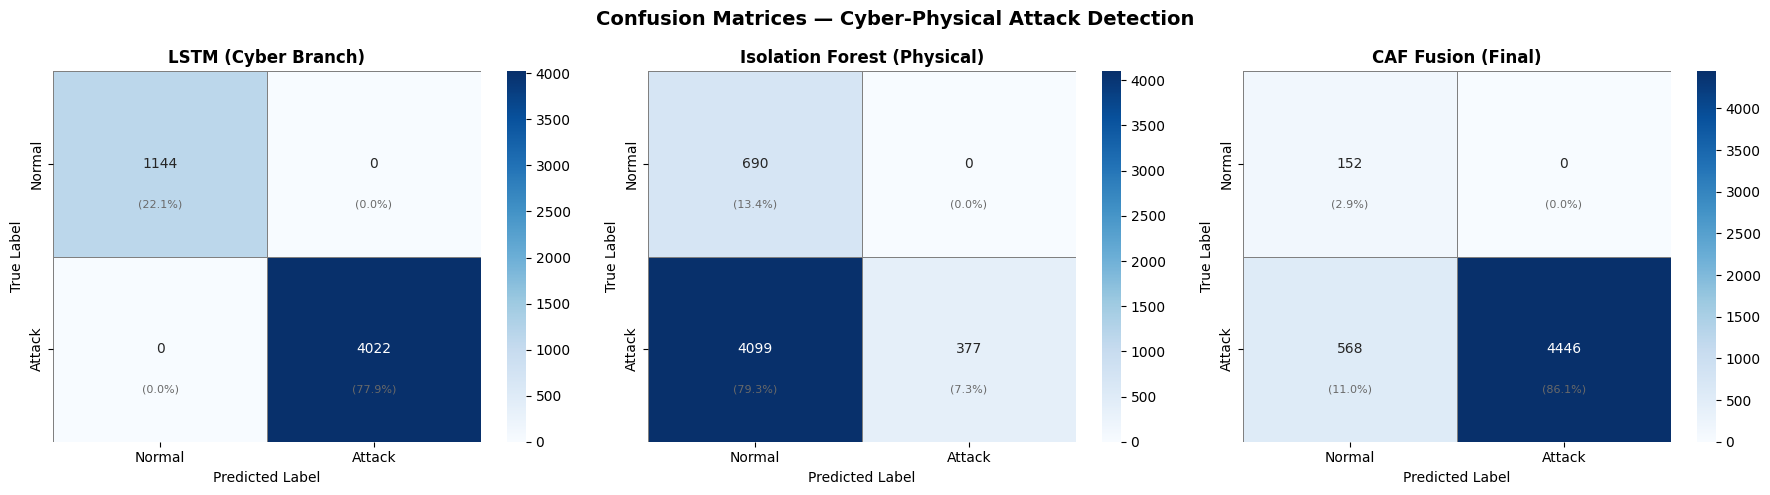

Saved: /content/confusion_matrices.png


In [ ]:
# Cell 11: Confusion Matrix Plots (3 models side by side)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Confusion Matrices — Cyber-Physical Attack Detection", fontsize=14, fontweight='bold')

datasets = [
    (y_c_test[:n_eval], y_lstm_pred,   "LSTM (Cyber Branch)"),
    (y_p_test[:n_eval], y_p_pred[:n_eval], "Isolation Forest (Physical)"),
    (y_true_fused,      y_pred_fused,  "CAF Fusion (Final)"),
]

for ax, (yt, yp, title) in zip(axes, datasets):
    cm = confusion_matrix(yt, yp)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal','Attack'],
                yticklabels=['Normal','Attack'],
                linewidths=0.5, linecolor='gray')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel("Predicted Label", fontsize=10)
    ax.set_ylabel("True Label", fontsize=10)
    # Add per-cell percentages
    total = cm.sum()
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j+0.5, i+0.72, f"({cm[i,j]/total*100:.1f}%)",
                    ha='center', va='center', fontsize=8, color='dimgray')

plt.tight_layout()
plt.savefig('/content/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: /content/confusion_matrices.png")

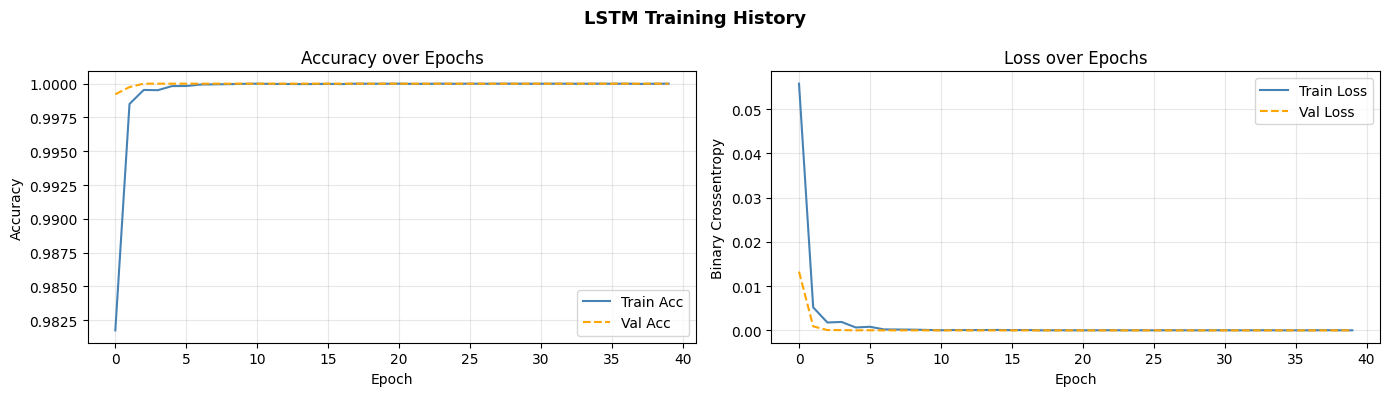

Saved: /content/lstm_training_history.png


In [ ]:
# Cell 12: LSTM Training History

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("LSTM Training History", fontsize=13, fontweight='bold')

axes[0].plot(history_lstm.history['accuracy'],     label='Train Acc',  color='steelblue')
axes[0].plot(history_lstm.history['val_accuracy'], label='Val Acc',    color='orange', linestyle='--')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history_lstm.history['loss'],     label='Train Loss', color='steelblue')
axes[1].plot(history_lstm.history['val_loss'], label='Val Loss',   color='orange', linestyle='--')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Binary Crossentropy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/lstm_training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: /content/lstm_training_history.png")

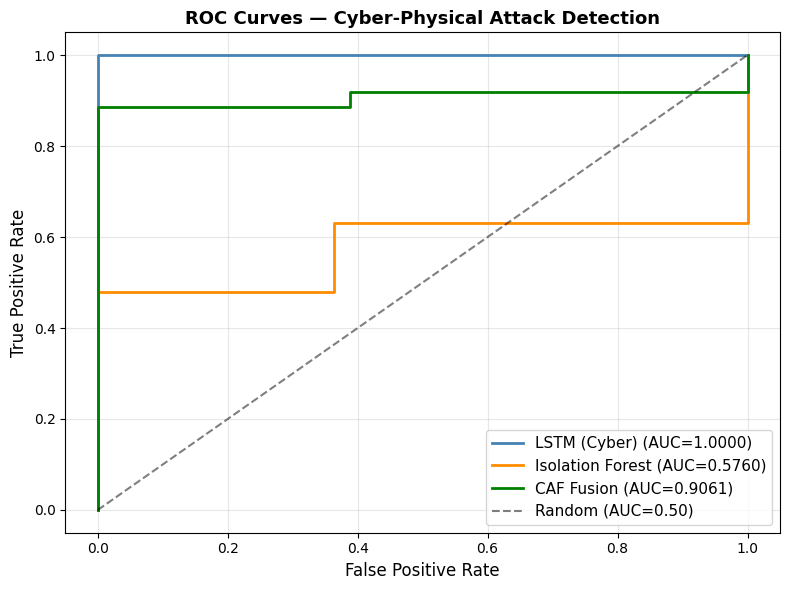

Saved: /content/roc_curves.png


In [ ]:
# Cell 13: ROC Curves — All 3 models

fig, ax = plt.subplots(figsize=(8, 6))

roc_data = [
    (y_c_test[:n_eval], p_cyber,        "LSTM (Cyber)",     "steelblue"),
    (y_p_test[:n_eval], p_phys,         "Isolation Forest", "darkorange"),
    (y_true_fused,      fusion_score,   "CAF Fusion",       "green"),
]

for y_t, y_s, label, color in roc_data:
    try:
        fpr, tpr, _ = roc_curve(y_t, y_s)
        auc_val = roc_auc_score(y_t, y_s)
        ax.plot(fpr, tpr, label=f"{label} (AUC={auc_val:.4f})", color=color, linewidth=2)
    except Exception as e:
        print(f"ROC skipped for {label}: {e}")

ax.plot([0,1],[0,1],'k--', alpha=0.5, label='Random (AUC=0.50)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — Cyber-Physical Attack Detection', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: /content/roc_curves.png")

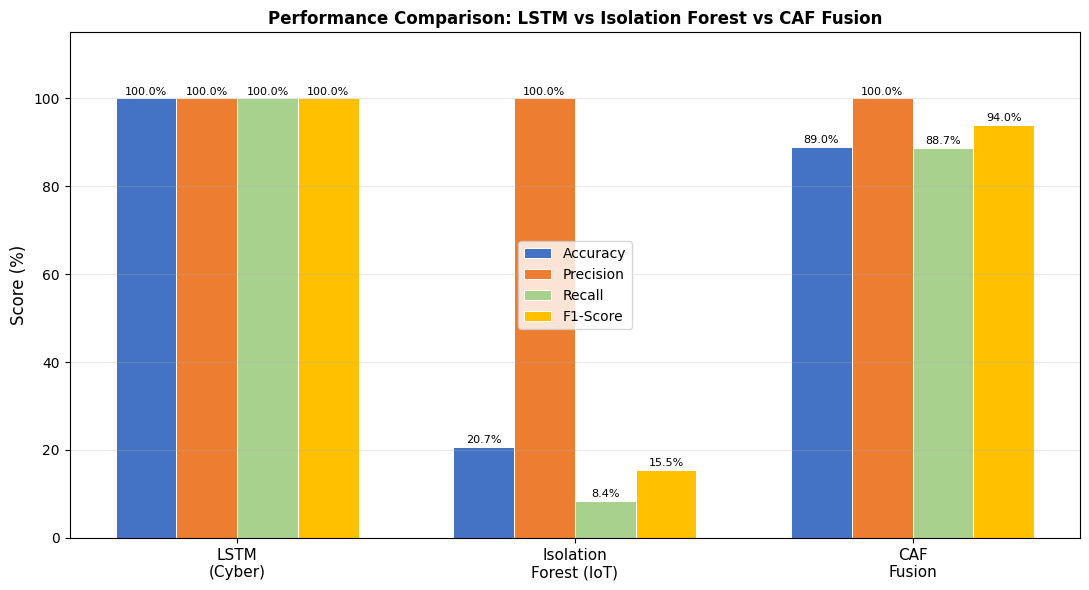

Saved: /content/performance_comparison.png


In [ ]:
# Cell 14: Performance Metrics Comparison Bar Chart

models     = ['LSTM\n(Cyber)', 'Isolation\nForest (IoT)', 'CAF\nFusion']
metrics_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
all_metrics    = [lstm_metrics, if_metrics, caf_metrics]  # each is (acc, prec, rec, f1, auc)

data_matrix = np.array([[m[i]*100 for m in all_metrics] for i in range(4)])  # shape (4, 3)

x      = np.arange(len(models))
width  = 0.18
colors = ['#4472C4', '#ED7D31', '#A9D18E', '#FFC000']

fig, ax = plt.subplots(figsize=(11, 6))
for i, (metric, color) in enumerate(zip(metrics_labels, colors)):
    bars = ax.bar(x + i*width - 1.5*width, data_matrix[i], width,
                  label=metric, color=color, edgecolor='white', linewidth=0.7)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Performance Comparison: LSTM vs Isolation Forest vs CAF Fusion',
             fontsize=12, fontweight='bold')
ax.set_ylim(0, 115)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/content/performance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: /content/performance_comparison.png")

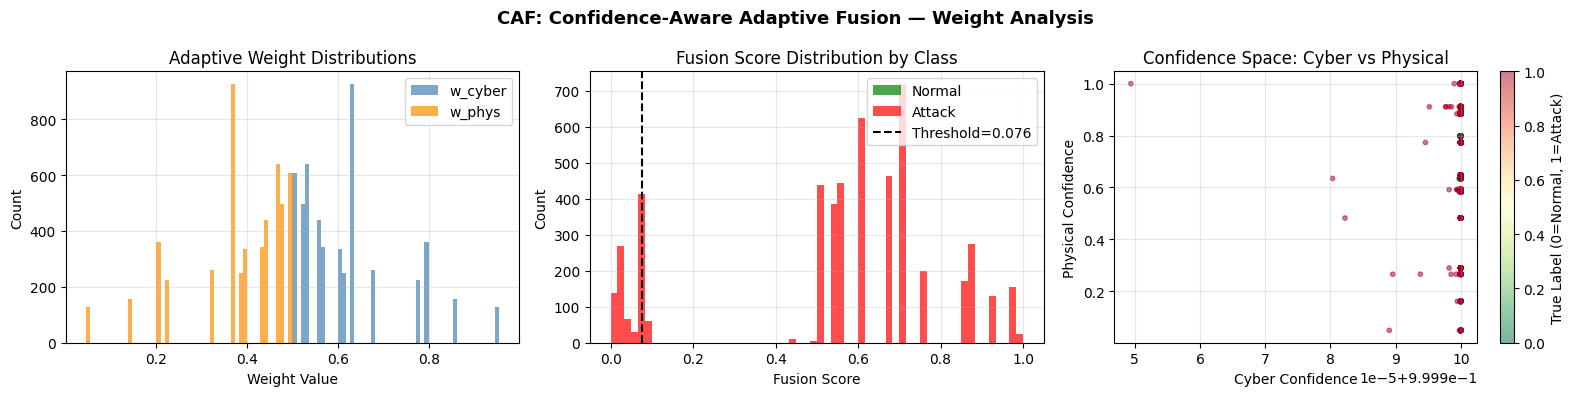

Saved: /content/caf_analysis.png


In [ ]:
# Cell 15: CAF Weight Distribution — Visualise your novel contribution

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("CAF: Confidence-Aware Adaptive Fusion — Weight Analysis", fontsize=13, fontweight='bold')

# Plot 1: Weight distributions
axes[0].hist(w_cyber, bins=50, alpha=0.7, color='steelblue',  label='w_cyber')
axes[0].hist(w_phys,  bins=50, alpha=0.7, color='darkorange', label='w_phys')
axes[0].set_title('Adaptive Weight Distributions')
axes[0].set_xlabel('Weight Value'); axes[0].set_ylabel('Count')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Plot 2: Fusion score distribution by class
mask_normal = y_true_fused == 0
mask_attack = y_true_fused == 1
axes[1].hist(fusion_score[mask_normal], bins=60, alpha=0.7, color='green',  label='Normal')
axes[1].hist(fusion_score[mask_attack], bins=60, alpha=0.7, color='red',    label='Attack')
axes[1].axvline(THRESHOLD, color='black', linestyle='--', linewidth=1.5, label=f'Threshold={THRESHOLD:.3f}')
axes[1].set_title('Fusion Score Distribution by Class')
axes[1].set_xlabel('Fusion Score'); axes[1].set_ylabel('Count')
axes[1].legend(); axes[1].grid(alpha=0.3)

# Plot 3: Cyber vs Physical confidence scatter (sample 2000)
idx = np.random.choice(len(conf_cyber), min(2000, len(conf_cyber)), replace=False)
sc  = axes[2].scatter(conf_cyber[idx], conf_phys[idx],
                      c=y_true_fused[idx], cmap='RdYlGn_r',
                      alpha=0.5, s=10)
plt.colorbar(sc, ax=axes[2], label='True Label (0=Normal, 1=Attack)')
axes[2].set_title('Confidence Space: Cyber vs Physical')
axes[2].set_xlabel('Cyber Confidence'); axes[2].set_ylabel('Physical Confidence')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/caf_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: /content/caf_analysis.png")

In [ ]:
# Cell 16: Final Summary Table (printed cleanly)

summary_df = pd.DataFrame({
    'Model':     ['LSTM (Cyber)', 'Isolation Forest (Physical)', 'CAF Fusion (Ours)'],
    'Accuracy':  [f"{lstm_metrics[0]*100:.2f}%", f"{if_metrics[0]*100:.2f}%", f"{caf_metrics[0]*100:.2f}%"],
    'Precision': [f"{lstm_metrics[1]*100:.2f}%", f"{if_metrics[1]*100:.2f}%", f"{caf_metrics[1]*100:.2f}%"],
    'Recall':    [f"{lstm_metrics[2]*100:.2f}%", f"{if_metrics[2]*100:.2f}%", f"{caf_metrics[2]*100:.2f}%"],
    'F1-Score':  [f"{lstm_metrics[3]*100:.2f}%", f"{if_metrics[3]*100:.2f}%", f"{caf_metrics[3]*100:.2f}%"],
    'ROC-AUC':   [f"{lstm_metrics[4]:.4f}",      f"{if_metrics[4]:.4f}",      f"{caf_metrics[4]:.4f}"],
})

print("\n" + "="*75)
print("  FINAL PERFORMANCE SUMMARY — Cyber-Physical Attack Detection System")
print("="*75)
print(summary_df.to_string(index=False))
print("="*75)
print(f"\n  CAF Fusion uses Confidence-Aware Adaptive Fusion (novel contribution)")
print(f"  Optimal fusion threshold (Youden's J): {THRESHOLD:.4f}")
print(f"  Mean cyber weight: {w_cyber.mean():.4f} | Mean physical weight: {w_phys.mean():.4f}")
print("="*75)


  FINAL PERFORMANCE SUMMARY — Cyber-Physical Attack Detection System
                      Model Accuracy Precision  Recall F1-Score ROC-AUC
               LSTM (Cyber)  100.00%   100.00% 100.00%  100.00%  1.0000
Isolation Forest (Physical)   20.65%   100.00%   8.42%   15.54%  0.5760
          CAF Fusion (Ours)   89.01%   100.00%  88.67%   94.00%  0.9061

  CAF Fusion uses Confidence-Aware Adaptive Fusion (novel contribution)
  Optimal fusion threshold (Youden's J): 0.0759
  Mean cyber weight: 0.6139 | Mean physical weight: 0.3861
